<a href="https://colab.research.google.com/github/HimanshiChoubal/Major_Project/blob/master/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q pennylane

import time, math, random, warnings
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from functools import partial
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
try:
    import pennylane as qml
    HAS_PL = True
except ImportError:
    HAS_PL = False
    print("PennyLane not found -> falling back to classical surrogate layer.")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = torch.device("cpu")   # default.qubit simulator runs on CPU
N_QUBITS = 4

print(f"torch {torch.__version__} | torchvision {torchvision.__version__} | "
      f"pennylane {qml.__version__ if HAS_PL else 'N/A'}")

# ---------------------------------------------------------------------------
# 4-qubit QCNN circuit (re-creation of CELL 4)
# ---------------------------------------------------------------------------
if HAS_PL:
    dev = qml.device("default.qubit", wires=N_QUBITS)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def qcnn_circuit(inputs, aqfs_gain, aqfs_phi, conv1, pool, conv2):
        # 1) RY/RZ angle encoding (batched over leading dim of `inputs`)
        for i in range(N_QUBITS):
            qml.RY(inputs[..., i], wires=i)
            qml.RZ(inputs[..., i], wires=i)
        # 2) Adaptive Quantum Feature Saliency (AQFS) block:
        #    learnable per-feature gains (data re-uploading) + trainable entangling ring
        for i in range(N_QUBITS):
            qml.RY(aqfs_gain[i] * inputs[..., i], wires=i)
        for i in range(N_QUBITS):
            qml.CRZ(aqfs_phi[i], wires=[i, (i + 1) % N_QUBITS])
        # 3) Convolution layer 1: SU(4) unitaries on neighbouring pairs
        qml.ArbitraryUnitary(conv1[0], wires=[0, 1])
        qml.ArbitraryUnitary(conv1[1], wires=[2, 3])
        # 4) Pooling: controlled-RY, then qubits 1 and 3 are discarded (partial trace)
        qml.CRY(pool[0], wires=[1, 0])
        qml.CRY(pool[1], wires=[3, 2])
        # 5) Convolution layer 2 on surviving qubits
        qml.ArbitraryUnitary(conv2[0], wires=[0, 2])
        return [qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(2))]

    WEIGHT_SHAPES = {"aqfs_gain": (4,), "aqfs_phi": (4,),
                     "conv1": (2, 15), "pool": (2,), "conv2": (1, 15)}
    INIT = {"aqfs_gain": nn.init.ones_,
            "aqfs_phi": partial(nn.init.normal_, std=0.3),
            "conv1":    partial(nn.init.normal_, std=0.3),
            "pool":     partial(nn.init.normal_, std=0.3),
            "conv2":    partial(nn.init.normal_, std=0.3)}

class ClassicalSurrogateLayer(nn.Module):
    """Fallback with the same I/O shape as the QCNN (4 -> 2, bounded)."""
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(N_QUBITS, 2)
    def forward(self, x):
        return torch.tanh(self.lin(x))

def build_quantum_layer():
    if HAS_PL:
        return qml.qnn.TorchLayer(qcnn_circuit, WEIGHT_SHAPES, init_method=INIT)
    return ClassicalSurrogateLayer()

# ---------------------------------------------------------------------------
# Hybrid model
# ---------------------------------------------------------------------------
class HybridQCNNClassifier(nn.Module):
    """4 PCA features -> QCNN (2 expectation values) -> Dropout/Linear head -> logit.
    forward() returns logits (use BCEWithLogitsLoss); predict_proba() returns P in [0,1]."""
    def __init__(self, hidden=8, dropout=0.1):
        super().__init__()
        self.qlayer = build_quantum_layer()
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        z = math.pi * torch.tanh(x.float())      # bound features to rotation range
        q = self.qlayer(z).float()
        return self.head(q).squeeze(-1)
    @torch.no_grad()
    def predict_proba(self, x):
        self.eval()
        return torch.sigmoid(self(x))             # anomaly probability in [0, 1]

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ---- smoke test: forward + autograd through the quantum layer ----
_m = HybridQCNNClassifier()
_x = torch.randn(8, 4)
_out = _m(_x); _out.sum().backward()
print("logits shape:", tuple(_out.shape), "| P range:",
      [round(v, 3) for v in (_m.predict_proba(_x).min().item(), _m.predict_proba(_x).max().item())])
print("trainable params:", count_params(_m))
if HAS_PL:
    print("quantum grads OK:", all(p.grad is not None for p in _m.qlayer.parameters()))
del _m, _x, _out

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 48.9 MB/s eta 0:00:00
torch 2.11.0+cpu | torchvision 0.26.0+cpu | pennylane 0.45.1
logits shape: (8,) | P range: [0.454, 0.473]
trainable params: 88
quantum grads OK: True


In [2]:
# ---------------------------------------------------------------------------
# Synthetic dataset (4 PCA features, Class 0 healthy / Class 1 critical)
# ---------------------------------------------------------------------------
GT_DELTA = np.array([1.6, 0.3, 1.4, 0.4])                  # class-mean separation per feature
GT_IMPORTANCE = np.abs(GT_DELTA) / np.abs(GT_DELTA).sum()  # ground-truth feature importance

def make_features(n, seed):
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n)
    x = rng.normal(0, 0.8, size=(n, 4))
    x[:, 1] += 0.3 * x[:, 0]                               # mild feature correlation
    x += (y[:, None] - 0.5) * GT_DELTA                     # class-conditional shift
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def apply_atmospheric_noise(X, sigma, seed=0):
    """Haze (signal attenuation) + sensor/atmospheric Gaussian noise."""
    g = torch.Generator().manual_seed(seed)
    haze = min(0.4 * sigma, 0.8)
    return X * (1 - haze) + sigma * torch.randn(X.shape, generator=g)

X_tr, y_tr = make_features(512, seed=1)
X_va, y_va = make_features(128, seed=2)
X_te, y_te = make_features(256, seed=3)

BATCH = 32
def make_loader(X, y, shuffle, seed=0):
    return DataLoader(TensorDataset(X, y), batch_size=BATCH, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(seed))
train_loader = make_loader(X_tr, y_tr, True)
val_loader   = make_loader(X_va, y_va, False)

# ---------------------------------------------------------------------------
# Metrics + generic trainer (reused for the classical baseline in CELL 7)
# ---------------------------------------------------------------------------
def acc_f1(logits, y):
    pred = (torch.sigmoid(logits) >= 0.5).float()
    tp = ((pred == 1) & (y == 1)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()
    acc = (pred == y).float().mean().item()
    f1 = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return acc, f1

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total, n, all_logits, all_y = 0.0, 0, [], []
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * len(yb); n += len(yb)
            all_logits.append(logits.detach()); all_y.append(yb)
    acc, f1 = acc_f1(torch.cat(all_logits), torch.cat(all_y))
    return total / n, acc, f1

def train_model(model, name, train_loader, val_loader, epochs=10, lr=0.05, verbose=True):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    keys = ["epoch", "train_loss", "train_acc", "train_f1",
            "val_loss", "val_acc", "val_f1", "time_s"]
    hist = {k: [] for k in keys}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta, tf = run_epoch(model, train_loader, criterion, optimizer)
        vl, va, vf = run_epoch(model, val_loader, criterion)
        dt = time.time() - t0
        for k, v in zip(keys, [ep, tl, ta, tf, vl, va, vf, dt]):
            hist[k].append(float(v))
        if verbose:
            print(f"[{name}] ep {ep:02d}/{epochs} | loss {tl:.4f} acc {ta:.3f} f1 {tf:.3f} "
                  f"| val loss {vl:.4f} acc {va:.3f} f1 {vf:.3f} | {dt:.2f}s")
    return hist

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    return acc_f1(model(X), y)

# ---------------------------------------------------------------------------
# Train the hybrid QCNN
# ---------------------------------------------------------------------------
EPOCHS, LR = 10, 0.05
set_seed(42)
qmodel = HybridQCNNClassifier()
print(f"Hybrid QCNN trainable parameters: {count_params(qmodel)}\n")
q_hist = train_model(qmodel, "QCNN", train_loader, val_loader, epochs=EPOCHS, lr=LR)

q_df = pd.DataFrame(q_hist).set_index("epoch").round(4)
display(q_df)
q_test_acc, q_test_f1 = evaluate(qmodel, X_te, y_te)
print(f"\nQCNN test  | accuracy: {q_test_acc:.4f} | F1: {q_test_f1:.4f} | "
      f"total train time: {sum(q_hist['time_s']):.1f}s")

Hybrid QCNN trainable parameters: 88

[QCNN] ep 01/10 | loss 0.6424 acc 0.633 f1 0.654 | val loss 0.5377 acc 0.812 f1 0.810 | 2.16s
[QCNN] ep 02/10 | loss 0.4199 acc 0.842 f1 0.846 | val loss 0.6318 acc 0.773 f1 0.743 | 1.95s
[QCNN] ep 03/10 | loss 0.3932 acc 0.826 f1 0.832 | val loss 0.4975 acc 0.805 f1 0.797 | 0.91s
[QCNN] ep 04/10 | loss 0.3887 acc 0.852 f1 0.856 | val loss 0.5382 acc 0.797 f1 0.787 | 0.90s
[QCNN] ep 05/10 | loss 0.3670 acc 0.855 f1 0.856 | val loss 0.4892 acc 0.781 f1 0.794 | 0.96s
[QCNN] ep 06/10 | loss 0.3841 acc 0.846 f1 0.852 | val loss 0.4867 acc 0.820 f1 0.816 | 1.00s
[QCNN] ep 07/10 | loss 0.3644 acc 0.861 f1 0.866 | val loss 0.4820 acc 0.789 f1 0.791 | 0.93s
[QCNN] ep 08/10 | loss 0.3589 acc 0.850 f1 0.856 | val loss 0.4788 acc 0.820 f1 0.816 | 1.18s
[QCNN] ep 09/10 | loss 0.3562 acc 0.859 f1 0.865 | val loss 0.5065 acc 0.805 f1 0.793 | 1.19s
[QCNN] ep 10/10 | loss 0.3544 acc 0.871 f1 0.875 | val loss 0.4934 acc 0.836 f1 0.832 | 0.93s


,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,time_s
epoch,,,,,,,
1.0,0.6424,0.6328,0.6544,0.5377,0.8125,0.8095,2.1622
2.0,0.4199,0.8418,0.8457,0.6318,0.7734,0.7434,1.9493
3.0,0.3932,0.8262,0.8324,0.4975,0.8047,0.7967,0.9078
4.0,0.3887,0.8516,0.8561,0.5382,0.7969,0.7869,0.8986
5.0,0.3670,0.8555,0.8560,0.4892,0.7812,0.7941,0.9645
6.0,0.3841,0.8457,0.8523,0.4867,0.8203,0.8160,1.0026
7.0,0.3644,0.8613,0.8658,0.4820,0.7891,0.7907,0.9346
8.0,0.3589,0.8496,0.8555,0.4788,0.8203,0.8160,1.1794
9.0,0.3562,0.8594,0.8647,0.5065,0.8047,0.7934,1.1878



QCNN test  | accuracy: 0.8242 | F1: 0.8276 | total train time: 12.1s


QCNN params: 88 | MLP hidden=6, params: 79

[MLP ] ep 01/10 | loss 0.3825 acc 0.799 f1 0.822 | val loss 0.3720 acc 0.875 f1 0.871 | 0.03s
[MLP ] ep 02/10 | loss 0.3059 acc 0.908 f1 0.908 | val loss 0.2730 acc 0.898 f1 0.898 | 0.04s
[MLP ] ep 03/10 | loss 0.2578 acc 0.910 f1 0.911 | val loss 0.2750 acc 0.883 f1 0.884 | 0.04s
[MLP ] ep 04/10 | loss 0.2540 acc 0.918 f1 0.920 | val loss 0.2668 acc 0.883 f1 0.884 | 0.03s
[MLP ] ep 05/10 | loss 0.2453 acc 0.916 f1 0.916 | val loss 0.2706 acc 0.891 f1 0.889 | 0.05s
[MLP ] ep 06/10 | loss 0.2434 acc 0.916 f1 0.916 | val loss 0.2660 acc 0.898 f1 0.896 | 0.04s
[MLP ] ep 07/10 | loss 0.2484 acc 0.916 f1 0.917 | val loss 0.2592 acc 0.891 f1 0.891 | 0.04s
[MLP ] ep 08/10 | loss 0.2446 acc 0.910 f1 0.911 | val loss 0.2563 acc 0.891 f1 0.894 | 0.03s
[MLP ] ep 09/10 | loss 0.2436 acc 0.914 f1 0.917 | val loss 0.2812 acc 0.883 f1 0.885 | 0.04s
[MLP ] ep 10/10 | loss 0.2434 acc 0.902 f1 0.905 | val loss 0.2647 acc 0.898 f1 0.901 | 0.04s


,Model,Params,Test Acc,Test F1,Train time (s)
0,Hybrid QCNN,88,0.8242,0.8276,12.1219
1,Classical MLP,79,0.8945,0.9011,0.3885


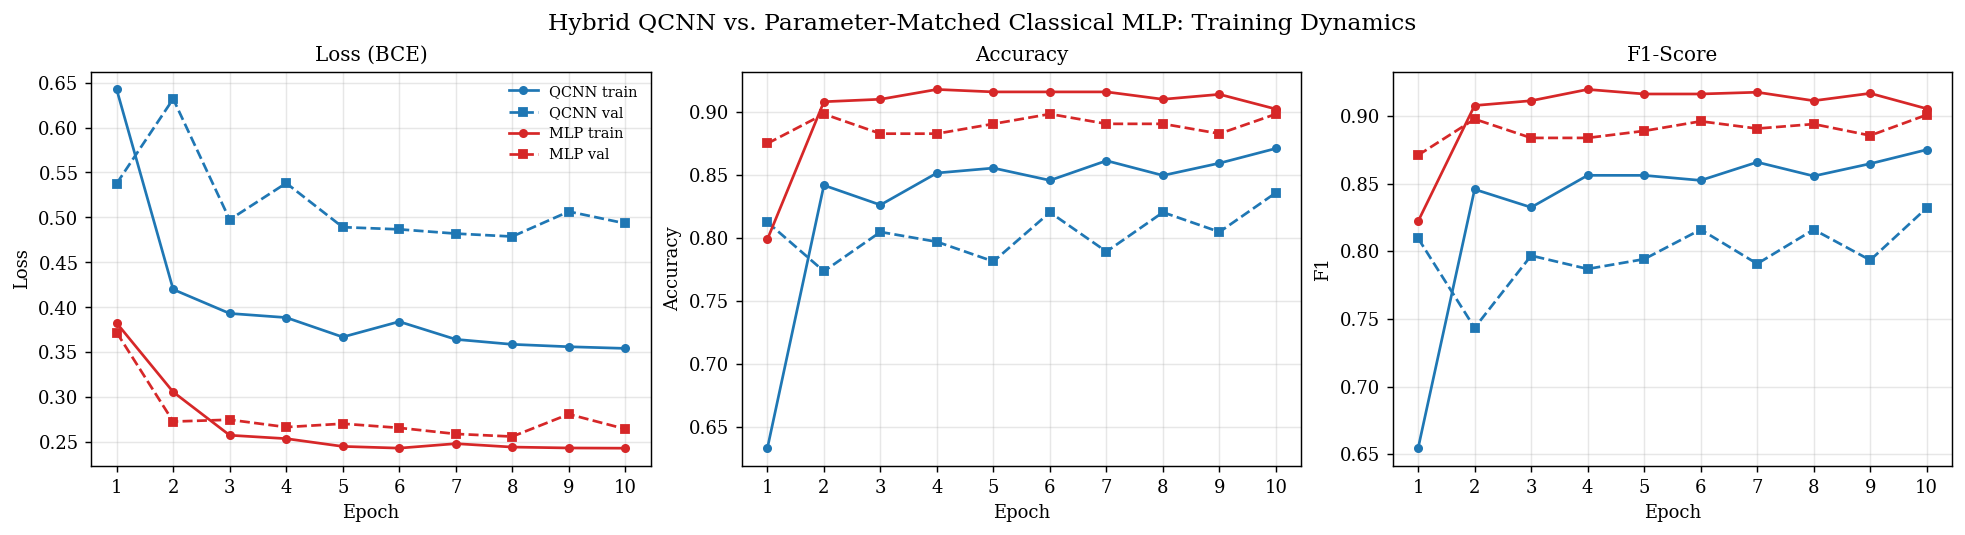

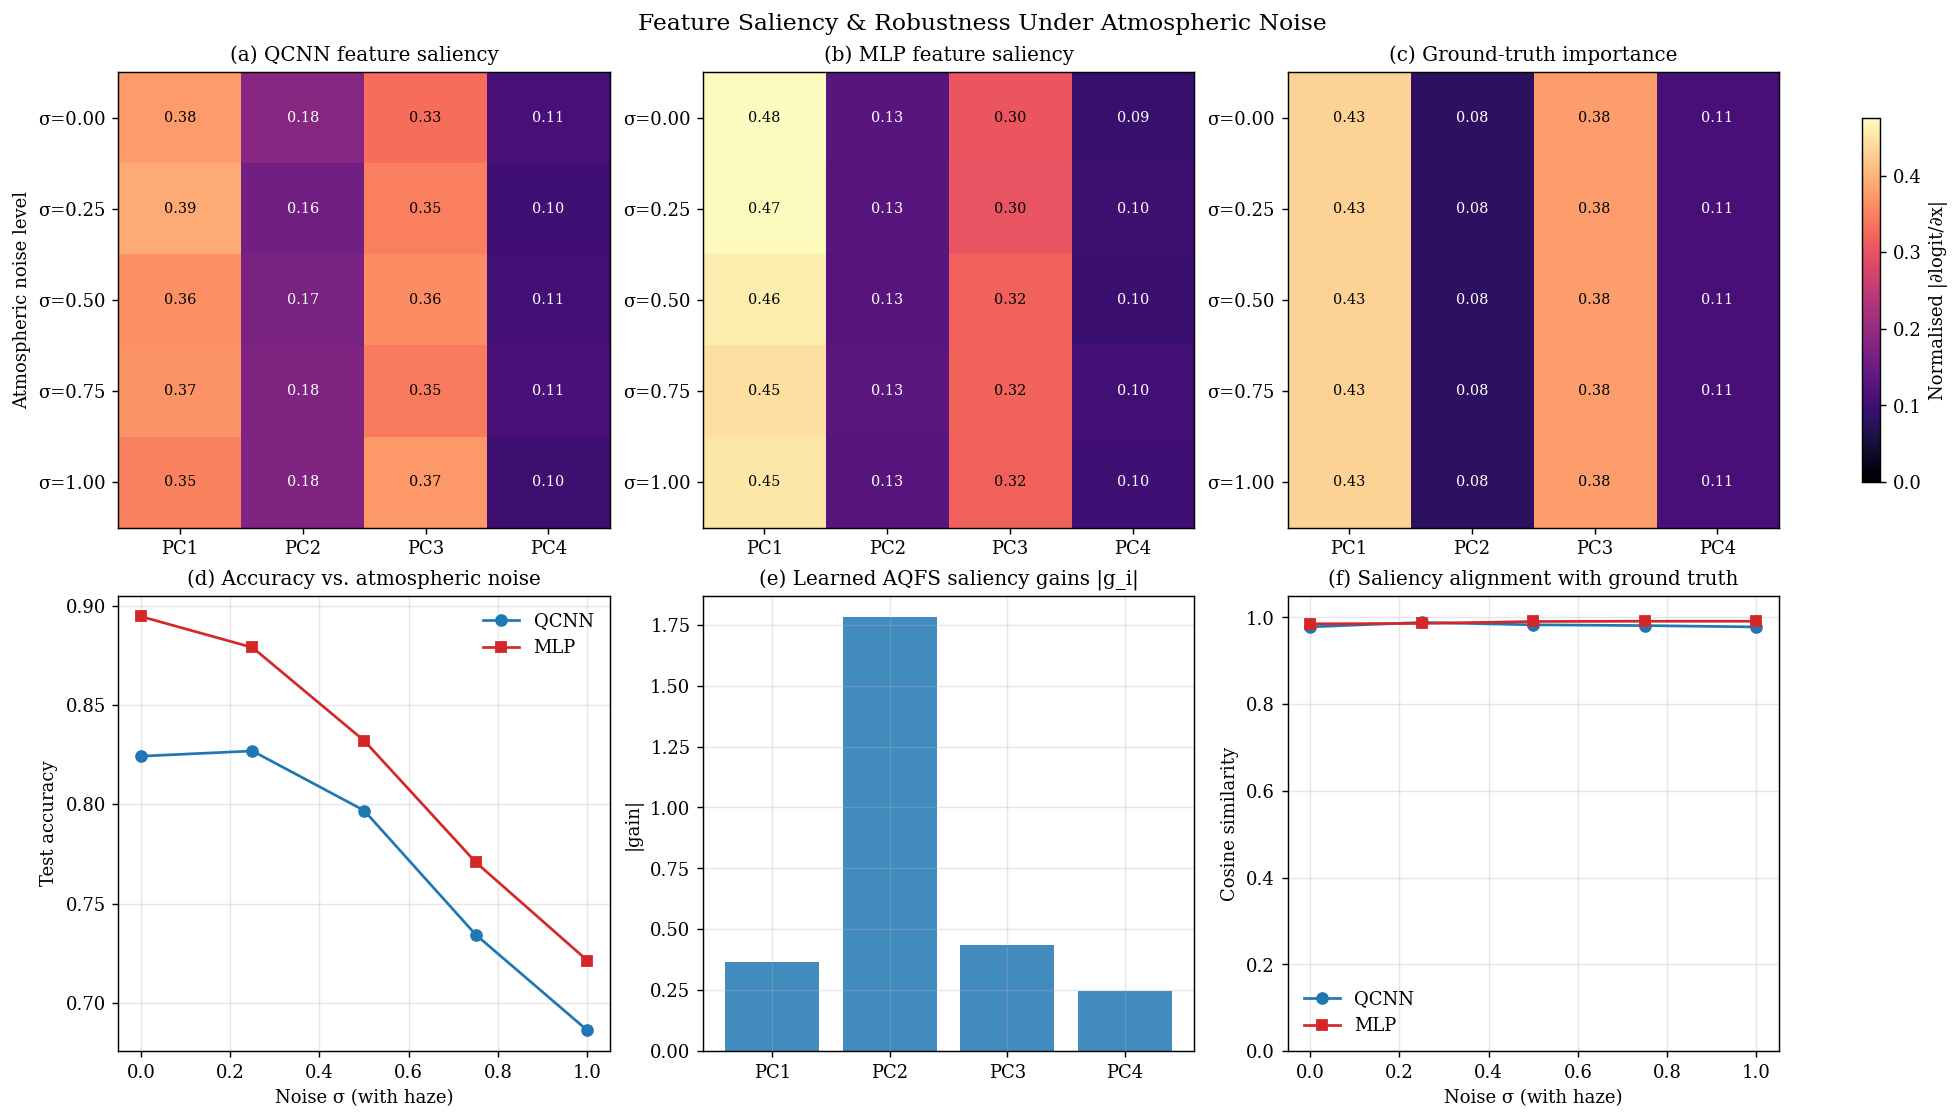

Saved: fig1_training_curves.png, fig2_saliency_robustness.png


In [3]:
# ---------------------------------------------------------------------------
# Parameter-matched classical MLP baseline
# ---------------------------------------------------------------------------
class ClassicalMLPBaseline(nn.Module):
    def __init__(self, hidden, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(math.pi * torch.tanh(x.float())).squeeze(-1)  # same input scaling

target = count_params(qmodel)
best_h = min(range(2, 65), key=lambda h: abs(count_params(ClassicalMLPBaseline(h)) - target))
set_seed(42)
cmodel = ClassicalMLPBaseline(best_h)
print(f"QCNN params: {target} | MLP hidden={best_h}, params: {count_params(cmodel)}\n")

c_hist = train_model(cmodel, "MLP ", train_loader, val_loader, epochs=EPOCHS, lr=LR)
c_test_acc, c_test_f1 = evaluate(cmodel, X_te, y_te)

summary = pd.DataFrame({
    "Model": ["Hybrid QCNN", "Classical MLP"],
    "Params": [count_params(qmodel), count_params(cmodel)],
    "Test Acc": [q_test_acc, c_test_acc],
    "Test F1": [q_test_f1, c_test_f1],
    "Train time (s)": [sum(q_hist["time_s"]), sum(c_hist["time_s"])],
}).round(4)
display(summary)

# ---------------------------------------------------------------------------
# Robustness + saliency under atmospheric noise
# ---------------------------------------------------------------------------
NOISE_LEVELS = [0.0, 0.25, 0.5, 0.75, 1.0]

def input_saliency(model, X):
    """Mean |d logit / d x| per feature, normalised to sum to 1."""
    model.eval()
    x = X.clone().requires_grad_(True)
    (g,) = torch.autograd.grad(model(x).sum(), x)
    s = g.abs().mean(0).detach().numpy()
    return s / (s.sum() + 1e-12)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

X_crit = X_te[y_te == 1]
acc_q, acc_c, sal_q, sal_c = [], [], [], []
for s in NOISE_LEVELS:
    aq, ac = [], []
    for rep in range(3):                                   # average over 3 noise draws
        Xn = apply_atmospheric_noise(X_te, s, seed=100 + rep)
        aq.append(evaluate(qmodel, Xn, y_te)[0]); ac.append(evaluate(cmodel, Xn, y_te)[0])
    acc_q.append(np.mean(aq)); acc_c.append(np.mean(ac))
    Xc = apply_atmospheric_noise(X_crit, s, seed=7)
    sal_q.append(input_saliency(qmodel, Xc)); sal_c.append(input_saliency(cmodel, Xc))

acc_q, acc_c = np.array(acc_q), np.array(acc_c)
sal_q, sal_c = np.stack(sal_q), np.stack(sal_c)            # (n_levels, 4)
cos_q = np.array([cosine(r, GT_IMPORTANCE) for r in sal_q])
cos_c = np.array([cosine(r, GT_IMPORTANCE) for r in sal_c])

# ---------------------------------------------------------------------------
# Publication-style figures
# ---------------------------------------------------------------------------
plt.rcParams.update({"font.family": "serif", "font.size": 10, "axes.titlesize": 11,
                     "axes.labelsize": 10, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 130, "savefig.dpi": 300})
QC, CC = "#1f77b4", "#d62728"
ep = np.array(q_hist["epoch"])

# ---- Figure 1: training curves ----
fig1, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, key, title, ylab in [(axs[0], "loss", "Loss (BCE)", "Loss"),
                             (axs[1], "acc", "Accuracy", "Accuracy"),
                             (axs[2], "f1", "F1-Score", "F1")]:
    ax.plot(ep, q_hist[f"train_{key}"], "-o", c=QC, ms=4, label="QCNN train")
    ax.plot(ep, q_hist[f"val_{key}"],   "--s", c=QC, ms=4, label="QCNN val")
    ax.plot(ep, c_hist[f"train_{key}"], "-o", c=CC, ms=4, label="MLP train")
    ax.plot(ep, c_hist[f"val_{key}"],   "--s", c=CC, ms=4, label="MLP val")
    ax.set(title=title, xlabel="Epoch", ylabel=ylab, xticks=ep)
axs[0].legend(frameon=False, fontsize=8)
fig1.suptitle("Hybrid QCNN vs. Parameter-Matched Classical MLP: Training Dynamics", fontsize=13)
fig1.savefig("fig1_training_curves.png", bbox_inches="tight")
plt.show()

# ---- Figure 2: saliency / robustness grid ----
fig2, axs = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)
FEATS = ["PC1", "PC2", "PC3", "PC4"]
gt_mat = np.tile(GT_IMPORTANCE, (len(NOISE_LEVELS), 1))
vmax = max(sal_q.max(), sal_c.max(), gt_mat.max())

def heat(ax, M, title):
    im = ax.imshow(M, cmap="magma", vmin=0, vmax=vmax, aspect="auto")
    ax.set(title=title, xticks=range(4), xticklabels=FEATS,
           yticks=range(len(NOISE_LEVELS)), yticklabels=[f"σ={s:.2f}" for s in NOISE_LEVELS])
    ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color="white" if M[i, j] < 0.6 * vmax else "black", fontsize=8)
    return im

im = heat(axs[0, 0], sal_q, "(a) QCNN feature saliency")
heat(axs[0, 1], sal_c, "(b) MLP feature saliency")
heat(axs[0, 2], gt_mat, "(c) Ground-truth importance")
fig2.colorbar(im, ax=axs[0, :], shrink=0.8, label="Normalised |∂logit/∂x|")
axs[0, 0].set_ylabel("Atmospheric noise level")

axs[1, 0].plot(NOISE_LEVELS, acc_q, "-o", c=QC, label="QCNN")
axs[1, 0].plot(NOISE_LEVELS, acc_c, "-s", c=CC, label="MLP")
axs[1, 0].set(title="(d) Accuracy vs. atmospheric noise", xlabel="Noise σ (with haze)",
              ylabel="Test accuracy"); axs[1, 0].legend(frameon=False)

if hasattr(qmodel.qlayer, "qnode_weights"):
    gains = qmodel.qlayer.qnode_weights["aqfs_gain"].detach().abs().numpy()
else:
    gains = np.zeros(4)
axs[1, 1].bar(FEATS, gains, color=QC, alpha=0.85)
axs[1, 1].set(title="(e) Learned AQFS saliency gains |g_i|", ylabel="|gain|")

axs[1, 2].plot(NOISE_LEVELS, cos_q, "-o", c=QC, label="QCNN")
axs[1, 2].plot(NOISE_LEVELS, cos_c, "-s", c=CC, label="MLP")
axs[1, 2].set(title="(f) Saliency alignment with ground truth", xlabel="Noise σ (with haze)",
              ylabel="Cosine similarity", ylim=(0, 1.05)); axs[1, 2].legend(frameon=False)

fig2.suptitle("Feature Saliency & Robustness Under Atmospheric Noise", fontsize=13)
fig2.savefig("fig2_saliency_robustness.png", bbox_inches="tight")
plt.show()

print("Saved: fig1_training_curves.png, fig2_saliency_robustness.png")

Sanity OK: MW(product)=0, MW(GHZ)=1, state-QNode matches the CELL 5 TorchLayer.
epoch 01 | train loss 0.6424 acc 0.633 | val loss 0.5377 acc 0.812
epoch 02 | train loss 0.4199 acc 0.842 | val loss 0.6318 acc 0.773
epoch 03 | train loss 0.3932 acc 0.826 | val loss 0.4975 acc 0.805
epoch 04 | train loss 0.3887 acc 0.852 | val loss 0.5382 acc 0.797
epoch 05 | train loss 0.3670 acc 0.855 | val loss 0.4892 acc 0.781
epoch 06 | train loss 0.3841 acc 0.846 | val loss 0.4867 acc 0.820
epoch 07 | train loss 0.3644 acc 0.861 | val loss 0.4820 acc 0.789
epoch 08 | train loss 0.3589 acc 0.850 | val loss 0.4788 acc 0.820
epoch 09 | train loss 0.3562 acc 0.859 | val loss 0.5065 acc 0.805
epoch 10 | train loss 0.3544 acc 0.871 | val loss 0.4934 acc 0.836


,MW_after_AQFS,MW_after_AQFS_std,MW_full_circuit,MW_full_circuit_std,KL_expressibility_data
epoch,,,,,
0,0.0007,0.0007,0.4981,0.1234,4.4865
1,0.0127,0.0071,0.4398,0.2064,1.4378
2,0.0055,0.0022,0.4642,0.1818,1.2364
3,0.0106,0.0035,0.4548,0.1849,1.3029
4,0.0111,0.0041,0.3869,0.1767,1.1308
5,0.0225,0.0084,0.3837,0.2008,1.1263
6,0.0281,0.0100,0.3999,0.1886,1.0770
7,0.0288,0.0112,0.3931,0.1946,1.0769
8,0.0404,0.0158,0.3920,0.1828,1.1298


,Setting,KL(P_circuit || P_Haar),Mean MW
0,Haar-sampled states (finite-sample floor),0.0001,0.8235
1,"Random theta, AQFS stage only",0.0872,0.3771
2,"Random theta, full QCNN",0.0013,0.6573
3,"Trained weights, epoch 0 (data states)",4.4865,0.4981
4,"Trained weights, epoch 10 (data states)",1.0659,0.4393


Lower KL = closer to Haar (more expressive). The Haar row is the estimator's noise floor.


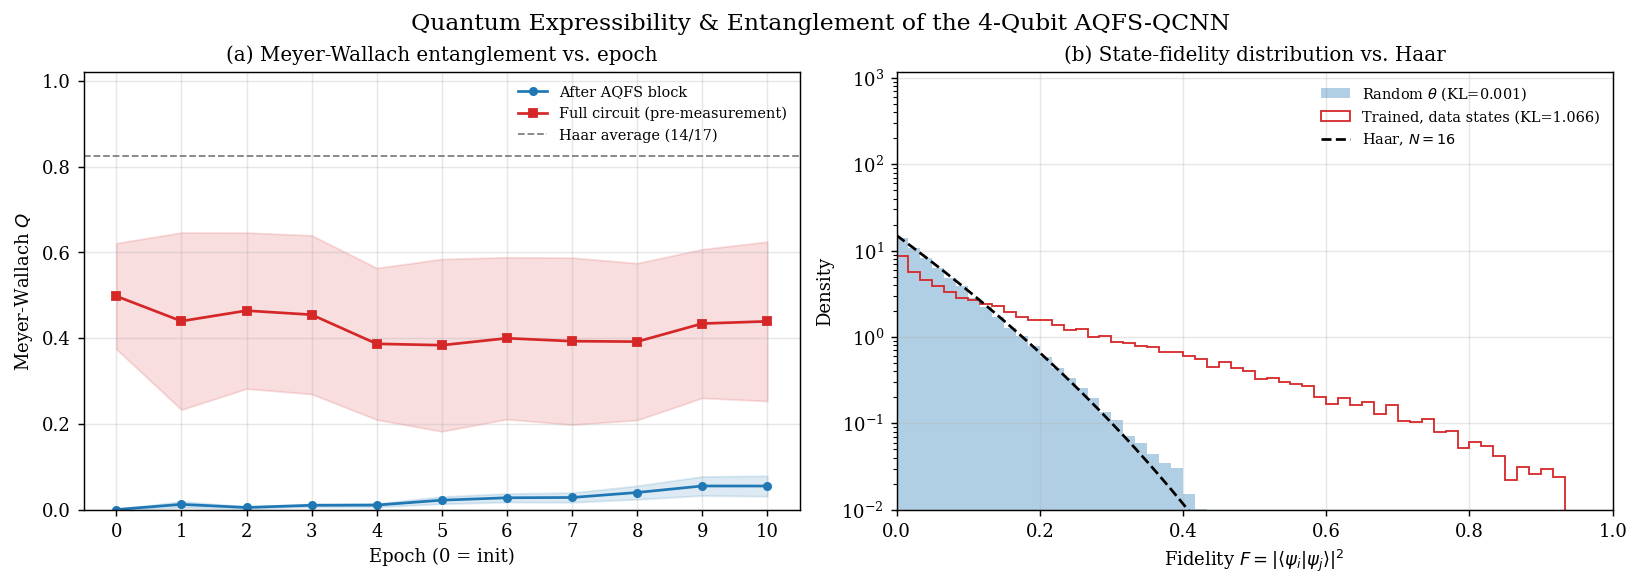

In [4]:
import math, time
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt

assert HAS_PL, "CELL 8 needs PennyLane (state-vector access). Re-run CELL 5 with PennyLane installed."

WKEYS = ("aqfs_gain", "aqfs_phi", "conv1", "pool", "conv2")
N_HILBERT = 2 ** N_QUBITS                                   # N = 16

# ---------------------------------------------------------------------------
# 8.1 State-vector QNodes (same gate sequence as CELL 5, but returning |psi>)
# ---------------------------------------------------------------------------
def qcnn_gates(inputs, aqfs_gain, aqfs_phi, conv1, pool, conv2, stage="full"):
    for i in range(N_QUBITS):                                # RY/RZ angle encoding
        qml.RY(inputs[..., i], wires=i); qml.RZ(inputs[..., i], wires=i)
    for i in range(N_QUBITS):                                # AQFS: learnable re-uploading gains
        qml.RY(aqfs_gain[i] * inputs[..., i], wires=i)
    for i in range(N_QUBITS):                                # AQFS: trainable entangling ring
        qml.CRZ(aqfs_phi[i], wires=[i, (i + 1) % N_QUBITS])
    if stage == "aqfs":
        return
    qml.ArbitraryUnitary(conv1[0], wires=[0, 1])             # SU(4) convolution
    qml.ArbitraryUnitary(conv1[1], wires=[2, 3])
    qml.CRY(pool[0], wires=[1, 0]); qml.CRY(pool[1], wires=[3, 2])   # pooling
    qml.ArbitraryUnitary(conv2[0], wires=[0, 2])

def make_state_qnode(stage):
    dev_s = qml.device("default.qubit", wires=N_QUBITS)
    @qml.qnode(dev_s, interface="torch")
    def f(inputs, aqfs_gain, aqfs_phi, conv1, pool, conv2):
        qcnn_gates(inputs, aqfs_gain, aqfs_phi, conv1, pool, conv2, stage=stage)
        return qml.state()
    return f

STATE_QN = {"aqfs": make_state_qnode("aqfs"), "full": make_state_qnode("full")}

def get_states(stage, z, w):
    """z: (B,4) float64 rotation angles; w: dict of float64 weight tensors -> (B,16) complex."""
    qn, args = STATE_QN[stage], [w[k] for k in WKEYS]
    try:                                                     # fast path: parameter broadcasting
        with torch.no_grad():
            s = qn(z, *args).detach().cpu().numpy()
        if s.ndim == 1: s = s[None]
        if s.shape[0] != z.shape[0]: raise ValueError("broadcast shape mismatch")
    except Exception:                                        # robust path: one sample at a time
        with torch.no_grad():
            s = np.stack([qn(z[i], *args).detach().cpu().numpy() for i in range(len(z))])
    return s

# ---------------------------------------------------------------------------
# 8.2 Metrics
# ---------------------------------------------------------------------------
def meyer_wallach(states):
    """Q = 2(1 - mean_k Tr rho_k^2) for each state. 0 = product state, 1 = maximal (e.g. GHZ)."""
    psi = np.asarray(states).reshape(-1, *([2] * N_QUBITS)); B = psi.shape[0]
    purities = []
    for k in range(N_QUBITS):
        m = np.moveaxis(psi, k + 1, 1).reshape(B, 2, -1)     # (B, qubit k, rest)
        rho = np.einsum("bia,bja->bij", m, m.conj())         # reduced density matrix of qubit k
        purities.append(np.real(np.einsum("bij,bji->b", rho, rho)))
    return 2.0 * (1.0 - np.mean(purities, axis=0))

def z_expect(states, wire):
    p = (np.abs(states) ** 2).reshape(-1, *([2] * N_QUBITS))
    marg = p.sum(axis=tuple(a for a in range(1, N_QUBITS + 1) if a != wire + 1))
    return marg[:, 0] - marg[:, 1]

def fidelity_pairs(states):
    """All unique pairwise fidelities |<psi_i|psi_j>|^2."""
    G = np.abs(states.conj() @ states.T) ** 2
    return G[np.triu_indices(len(states), k=1)]

def haar_pdf(f):                                             # P_Haar(F) = (N-1)(1-F)^(N-2)
    return (N_HILBERT - 1) * (1.0 - f) ** (N_HILBERT - 2)

def expressibility_kl(fid, n_bins=75):
    counts, edges = np.histogram(fid, bins=n_bins, range=(0, 1))
    p = counts / counts.sum()
    q = (1 - edges[:-1]) ** (N_HILBERT - 1) - (1 - edges[1:]) ** (N_HILBERT - 1)   # exact Haar bin mass
    m = p > 0
    return float(np.sum(p[m] * np.log(p[m] / (q[m] + 1e-12))))

def haar_states(n, rng):
    g = rng.standard_normal((n, N_HILBERT)) + 1j * rng.standard_normal((n, N_HILBERT))
    return g / np.linalg.norm(g, axis=1, keepdims=True)

# ---- sanity checks (fail loudly if anything is mis-wired) ----
prod = np.zeros((1, N_HILBERT), complex); prod[0, 0] = 1
ghz = np.zeros((1, N_HILBERT), complex); ghz[0, 0] = ghz[0, -1] = 1 / np.sqrt(2)
assert abs(meyer_wallach(prod)[0]) < 1e-9 and abs(meyer_wallach(ghz)[0] - 1) < 1e-9
w_chk = {k: v.detach().double() for k, v in qmodel.qlayer.qnode_weights.items()}
z_chk = (math.pi * torch.tanh(X_te[:16])).double()
st_chk = get_states("full", z_chk, w_chk)
with torch.no_grad():
    ref = qmodel.qlayer(z_chk.float()).numpy()
np.testing.assert_allclose(np.stack([z_expect(st_chk, 0), z_expect(st_chk, 2)], 1), ref, atol=1e-4)
print("Sanity OK: MW(product)=0, MW(GHZ)=1, state-QNode matches the CELL 5 TorchLayer.")

# ---------------------------------------------------------------------------
# 8.3 Retrain (same seed/loaders/hyper-params) while snapshotting weights per epoch
# ---------------------------------------------------------------------------
def snapshot(model):
    return {k: v.detach().clone().double() for k, v in model.qlayer.qnode_weights.items()}

set_seed(42)
q8 = HybridQCNNClassifier()
tr8, va8 = make_loader(X_tr, y_tr, True), make_loader(X_va, y_va, False)
crit8, opt8 = nn.BCEWithLogitsLoss(), torch.optim.Adam(q8.parameters(), lr=LR)
W_BY_EPOCH = [snapshot(q8)]                                  # index 0 = initialisation
for e in range(1, EPOCHS + 1):
    tl, ta, tf = run_epoch(q8, tr8, crit8, opt8)
    vl, va_, vf = run_epoch(q8, va8, crit8)
    W_BY_EPOCH.append(snapshot(q8))
    print(f"epoch {e:02d} | train loss {tl:.4f} acc {ta:.3f} | val loss {vl:.4f} acc {va_:.3f}")

# ---------------------------------------------------------------------------
# 8.4 Per-epoch Meyer-Wallach + data-state expressibility
# ---------------------------------------------------------------------------
N_AN = 256
z_an = (math.pi * torch.tanh(X_tr[:N_AN])).double()
rows, FID_BY_EPOCH = [], {}
for e, w in enumerate(W_BY_EPOCH):
    s_a, s_f = get_states("aqfs", z_an, w), get_states("full", z_an, w)
    mw_a, mw_f = meyer_wallach(s_a), meyer_wallach(s_f)
    FID_BY_EPOCH[e] = fidelity_pairs(s_f)
    rows.append(dict(epoch=e, MW_after_AQFS=mw_a.mean(), MW_after_AQFS_std=mw_a.std(),
                     MW_full_circuit=mw_f.mean(), MW_full_circuit_std=mw_f.std(),
                     KL_expressibility_data=expressibility_kl(FID_BY_EPOCH[e])))
df8 = pd.DataFrame(rows).set_index("epoch").round(4)
display(df8)

# ---------------------------------------------------------------------------
# 8.5 Circuit-family expressibility (random theta ~ U[0, 2pi), data inputs)
# ---------------------------------------------------------------------------
N_RAND = 600
rng8 = np.random.default_rng(0)
z_pool = (math.pi * torch.tanh(X_tr)).double()
rand_states = {"aqfs": [], "full": []}
for _ in range(N_RAND):
    w = {k: torch.tensor(rng8.uniform(0, 2 * np.pi, size=shape), dtype=torch.float64)
         for k, shape in WEIGHT_SHAPES.items()}
    zi = z_pool[int(rng8.integers(len(z_pool)))][None]
    for stg in rand_states:
        rand_states[stg].append(get_states(stg, zi, w)[0])
rand_states = {k: np.stack(v) for k, v in rand_states.items()}
FID_RAND = {k: fidelity_pairs(v) for k, v in rand_states.items()}
FID_HAAR = fidelity_pairs(haar_states(N_RAND, rng8))

expr_table = pd.DataFrame({
    "Setting": ["Haar-sampled states (finite-sample floor)", "Random theta, AQFS stage only",
                "Random theta, full QCNN", "Trained weights, epoch 0 (data states)",
                f"Trained weights, epoch {EPOCHS} (data states)"],
    "KL(P_circuit || P_Haar)": [expressibility_kl(FID_HAAR), expressibility_kl(FID_RAND["aqfs"]),
                                expressibility_kl(FID_RAND["full"]),
                                df8.loc[0, "KL_expressibility_data"], df8.loc[EPOCHS, "KL_expressibility_data"]],
    "Mean MW": [np.mean(meyer_wallach(haar_states(N_RAND, rng8))), np.mean(meyer_wallach(rand_states["aqfs"])),
                np.mean(meyer_wallach(rand_states["full"])),
                df8.loc[0, "MW_full_circuit"], df8.loc[EPOCHS, "MW_full_circuit"]],
}).round(4)
display(expr_table)
print("Lower KL = closer to Haar (more expressive). The Haar row is the estimator's noise floor.")

# ---------------------------------------------------------------------------
# 8.6 Figure (1 x 2)
# ---------------------------------------------------------------------------
ep_arr = df8.index.values
fig8, axs = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True)

ax = axs[0]
for col, lab, c, mk in [("MW_after_AQFS", "After AQFS block", "#1f77b4", "o"),
                        ("MW_full_circuit", "Full circuit (pre-measurement)", "#d62728", "s")]:
    m, s = df8[col].values, df8[col + "_std"].values
    ax.plot(ep_arr, m, f"-{mk}", c=c, ms=4, label=lab)
    ax.fill_between(ep_arr, np.clip(m - s, 0, 1), np.clip(m + s, 0, 1), color=c, alpha=0.15)
ax.axhline(14 / 17, ls="--", c="gray", lw=1, label="Haar average (14/17)")
ax.set(title="(a) Meyer-Wallach entanglement vs. epoch", xlabel="Epoch (0 = init)",
       ylabel="Meyer-Wallach $Q$", ylim=(0, 1.02), xticks=ep_arr)
ax.legend(frameon=False, fontsize=8)

ax = axs[1]
bins = np.linspace(0, 1, 61); fgrid = np.linspace(0, 1, 500)
ax.hist(FID_RAND["full"], bins=bins, density=True, alpha=0.35, color="#1f77b4",
        label=f"Random $\\theta$ (KL={expr_table.iloc[2, 1]:.3f})")
ax.hist(FID_BY_EPOCH[EPOCHS], bins=bins, density=True, histtype="step", lw=1.8, color="#d62728",
        label=f"Trained, data states (KL={df8.loc[EPOCHS, 'KL_expressibility_data']:.3f})")
ax.plot(fgrid, haar_pdf(fgrid), "k--", lw=1.5, label=f"Haar, $N={N_HILBERT}$")
ax.set(title="(b) State-fidelity distribution vs. Haar", xlabel="Fidelity $F=|\\langle\\psi_i|\\psi_j\\rangle|^2$",
       ylabel="Density", yscale="log", ylim=(1e-2, None), xlim=(0, 1))
ax.legend(frameon=False, fontsize=8)
fig8.suptitle("Quantum Expressibility & Entanglement of the 4-Qubit AQFS-QCNN", fontsize=13)
fig8.savefig("fig3_expressibility_entanglement.png", bbox_inches="tight", dpi=300)
plt.show()

Realised SNR (dB) of each corruption:


,Gaussian,Speckle (SAR),Cloud cover
15 dB (nominal),14.99,14.99,15.00
10 dB (nominal),9.99,9.99,10.00
5 dB (nominal),4.99,5.00,5.24


seed 0 done in 12s | clean F1: Hybrid QCNN=0.663, Classical CNN=0.989, MLP on PCA (ablation)=0.745
seed 1 done in 11s | clean F1: Hybrid QCNN=0.726, Classical CNN=0.988, MLP on PCA (ablation)=0.759
seed 2 done in 12s | clean F1: Hybrid QCNN=0.690, Classical CNN=0.972, MLP on PCA (ablation)=0.724
Trainable parameters: {'Hybrid QCNN': 88, 'Classical CNN': 1481, 'MLP on PCA (ablation)': 79}


F1 Clean     F1 15 dB     F1 10 dB  \
Noise         Model                                                          
Gaussian      Hybrid QCNN            0.693±0.026  0.688±0.023  0.696±0.010   
              Classical CNN          0.983±0.008  0.754±0.041  0.706±0.003   
              MLP on PCA (ablation)  0.743±0.014  0.738±0.005  0.721±0.001   
Speckle (SAR) Hybrid QCNN            0.693±0.026  0.685±0.014  0.693±0.007   
              Classical CNN          0.983±0.008  0.755±0.047  0.708±0.005   
              MLP on PCA (ablation)  0.743±0.014  0.732±0.022  0.726±0.018   
Cloud cover   Hybrid QCNN            0.693±0.026  0.564±0.016  0.447±0.008   
              Classical CNN          0.983±0.008  0.715±0.013  0.703±0.000   
              MLP on PCA (ablation)  0.743±0.014  0.558±0.029  0.463±0.033   

                                         F1 5 dB Acc Clean Acc 15 dB  \
Noise         Model                                                    
Gaussian      Hybrid QCNN            0.684±0.011     0.697     0.687   
              Classical CNN          0.703±0.000     0.982     0.642   
              MLP on PCA (ablation)  0.707±0.013     0.749     0.743   
Speckle (SAR) Hybrid QCNN            0.685±0.016     0.697     0.685   
              Classical CNN          0.703±0.000     0.982     0.642   
              MLP on PCA (ablation)  0.712±0.006     0.749     0.740   
Cloud cover   Hybrid QCNN            0.413±0.027     0.697     0.597   
              Classical CNN          0.703±0.000     0.982     0.566   
              MLP on PCA (ablation)  0.453±0.046     0.749     0.599   

                                    Acc 10 dB Acc 5 dB  
Noise         Model                                     
Gaussian      Hybrid QCNN               0.691    0.668  
              Classical CNN             0.548    0.543  
              MLP on PCA (ablation)     0.726    0.708  
Speckle (SAR) Hybrid QCNN               0.690    0.675  
              Classical CNN             0.552    0.543  
              MLP on PCA (ablation)     0.729    0.712  
Cloud cover   Hybrid QCNN               0.512    0.468  
              Classical CNN             0.543    0.543  
              MLP on PCA (ablation)     0.520    0.470

Mean F1 difference (positive = QCNN better):


Clean  15 dB  10 dB   5 dB
Noise         QCNN minus                                       
Gaussian      Classical CNN         -0.290 -0.065 -0.010 -0.020
              MLP on PCA (ablation) -0.049 -0.049 -0.025 -0.023
Speckle (SAR) Classical CNN         -0.290 -0.070 -0.015 -0.018
              MLP on PCA (ablation) -0.049 -0.047 -0.033 -0.026
Cloud cover   Classical CNN         -0.290 -0.151 -0.257 -0.290
              MLP on PCA (ablation) -0.049  0.006 -0.017 -0.040

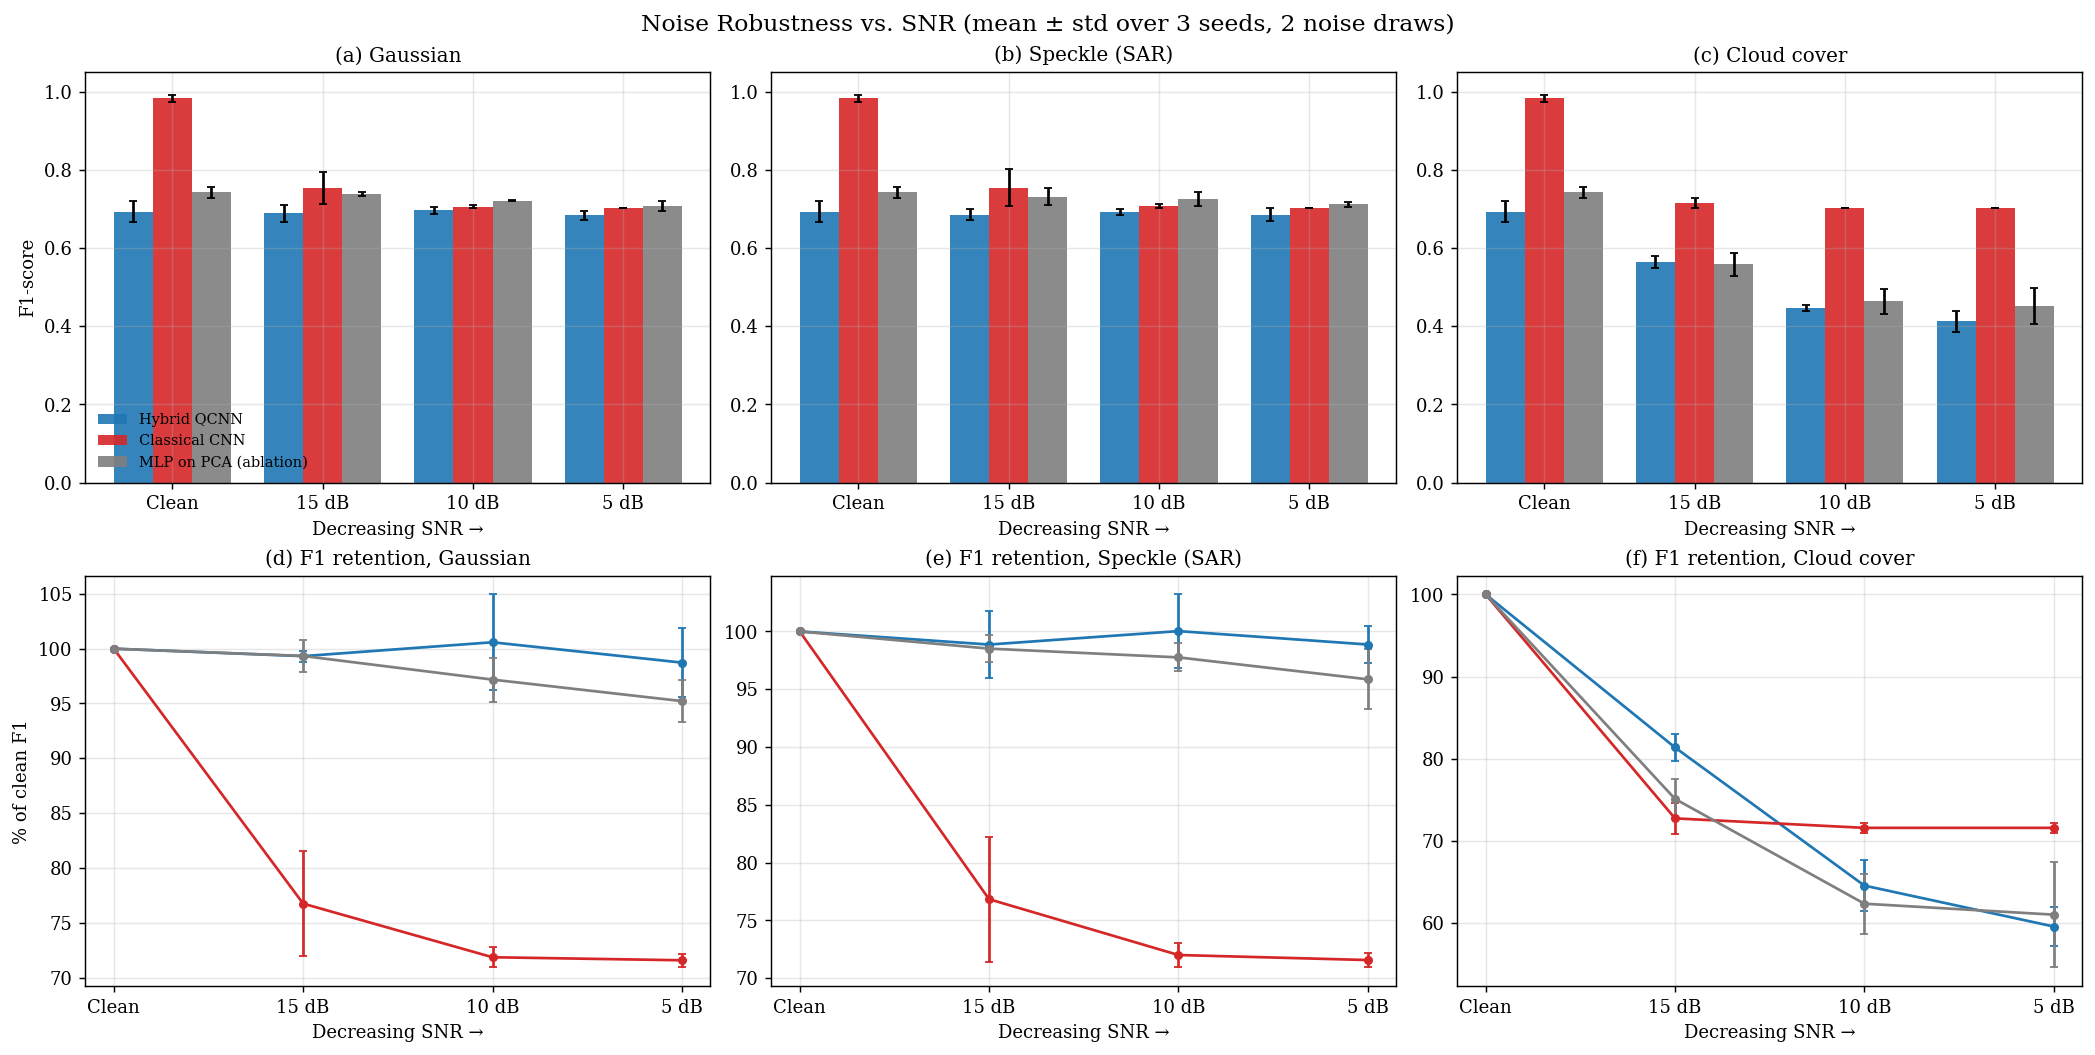

In [5]:
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as Fn
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 9.1 Synthetic 4-channel (R,G,B,NIR) patches
# ---------------------------------------------------------------------------
PATCH, GAP_SCALE = 16, 0.6          # raise GAP_SCALE to make the task easier, lower to make it harder
HEALTHY_MEAN = np.array([0.45, 0.50, 0.42, 0.65])
CLASS_SHIFT  = np.array([0.04, 0.05, 0.04, 0.13])     # degraded assets: lower reflectance, esp. NIR
CRACK_DEPTH  = np.array([0.10, 0.10, 0.10, 0.14])

def _upsample(a):
    return Fn.interpolate(torch.from_numpy(a).float(), size=(PATCH, PATCH),
                          mode="bilinear", align_corners=False).numpy()

def _stamp_line(mask, rng):
    x0, y0 = rng.uniform(0, PATCH, 2); th = rng.uniform(0, np.pi); L = rng.uniform(6, 14)
    t = np.linspace(0, L, int(4 * L))
    ix = np.round(x0 + t * np.cos(th)).astype(int); iy = np.round(y0 + t * np.sin(th)).astype(int)
    ok = (ix >= 0) & (ix < PATCH) & (iy >= 0) & (iy < PATCH)
    mask[iy[ok], ix[ok]] = 1.0

def make_patches(n, seed):
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n)
    means = HEALTHY_MEAN[None] - GAP_SCALE * CLASS_SHIFT[None] * y[:, None]          # (n,4)
    x = np.broadcast_to(means[:, :, None, None], (n, 4, PATCH, PATCH)).copy()
    x += 0.04 * _upsample(rng.standard_normal((n, 1, 4, 4))) \
       + 0.015 * _upsample(rng.standard_normal((n, 4, 4, 4)))                          # smooth background
    x *= 1 + 0.08 * rng.standard_normal((n, 1, 1, 1))                                  # exposure nuisance
    x += 0.02 * rng.standard_normal(x.shape)                                           # sensor noise
    crack, faint = np.zeros((n, PATCH, PATCH)), np.zeros((n, PATCH, PATCH))
    for i in range(n):
        if y[i] == 1:
            for _ in range(int(rng.integers(2, 4))): _stamp_line(crack[i], rng)        # micro-fissures
        elif rng.random() < 0.5:
            _stamp_line(faint[i], rng)                                                 # benign bright joint
    x = x - CRACK_DEPTH[None, :, None, None] * crack[:, None] + 0.05 * faint[:, None]
    return torch.tensor(np.clip(x, 0, 1), dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

Xp_tr, yp_tr = make_patches(480, 11)
Xp_va, yp_va = make_patches(120, 12)
Xp_te, yp_te = make_patches(400, 13)

# ---------------------------------------------------------------------------
# 9.2 Noise models (exact SNR targets, per-patch signal power)
# ---------------------------------------------------------------------------
def _sig_power(x): return x.pow(2).mean(dim=(1, 2, 3), keepdim=True)

def add_gaussian_noise(x, snr_db, rng):
    """Additive white Gaussian atmospheric/sensor noise."""
    sigma = torch.sqrt(_sig_power(x) / 10 ** (snr_db / 10))
    return x + sigma * torch.from_numpy(rng.standard_normal(tuple(x.shape))).float()

def add_speckle_noise(x, snr_db, rng):
    """Multiplicative L-look Gamma speckle (SAR). E[s]=1, Var[s]=1/L  =>  SNR = L."""
    L = 10 ** (snr_db / 10)
    s = torch.from_numpy(rng.gamma(shape=L, scale=1.0 / L, size=tuple(x.shape))).float()
    return x * s

CLOUD_REFL = torch.tensor([0.92, 0.93, 0.94, 0.85]).view(1, 4, 1, 1)   # bright in all bands

def add_cloud_cover(x, snr_db, rng):
    """Translucent cloud: x' = (1-a)x + a*c with smooth opacity a; opacity scaled to hit the SNR."""
    n = x.shape[0]
    fld = Fn.interpolate(torch.from_numpy(rng.standard_normal((n, 1, 4, 4))).float(),
                         size=x.shape[-2:], mode="bilinear", align_corners=False)
    lo, hi = fld.amin(dim=(1, 2, 3), keepdim=True), fld.amax(dim=(1, 2, 3), keepdim=True)
    a0 = (fld - lo) / (hi - lo + 1e-8)                                   # unit-range cloud shape
    e0 = a0 * (CLOUD_REFL - x)                                           # additive corruption for unit scale
    k = torch.sqrt(_sig_power(x) / (10 ** (snr_db / 10) * e0.pow(2).mean(dim=(1, 2, 3), keepdim=True) + 1e-12))
    alpha = (k * a0).clamp(0, 1)
    return (1 - alpha) * x + alpha * CLOUD_REFL

NOISE_FNS = {"Gaussian": add_gaussian_noise, "Speckle (SAR)": add_speckle_noise, "Cloud cover": add_cloud_cover}

def realised_snr(clean, noisy):
    ps = clean.pow(2).mean(dim=(1, 2, 3)); pn = (noisy - clean).pow(2).mean(dim=(1, 2, 3))
    return (10 * torch.log10(ps / (pn + 1e-12))).mean().item()

SNR_LIST = [15, 10, 5]
chk = pd.DataFrame({nz: [realised_snr(Xp_te, fn(Xp_te, s, np.random.default_rng(0))) for s in SNR_LIST]
                    for nz, fn in NOISE_FNS.items()}, index=[f"{s} dB (nominal)" for s in SNR_LIST]).round(2)
print("Realised SNR (dB) of each corruption:"); display(chk)

# ---------------------------------------------------------------------------
# 9.3 PCA front-end (fit on clean training patches only) + models
# ---------------------------------------------------------------------------
class PCAProjector:
    def fit(self, X, k=4):
        A = X.reshape(len(X), -1).double(); self.mu = A.mean(0, keepdim=True)
        _, _, Vh = torch.linalg.svd(A - self.mu, full_matrices=False)
        self.comp = Vh[:k]
        self.sd = ((A - self.mu) @ self.comp.T).std(0, keepdim=True)
        return self
    def transform(self, X):
        A = X.reshape(len(X), -1).double()
        return (((A - self.mu) @ self.comp.T) / self.sd).float()

pca = PCAProjector().fit(Xp_tr)
Fp_tr, Fp_va = pca.transform(Xp_tr), pca.transform(Xp_va)

class ClassicalCNN(nn.Module):
    """Small 2-D CNN on raw 4x16x16 patches (more parameters than the QCNN -> conservative baseline)."""
    def __init__(self, c1=8, c2=16, dropout=0.1):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(4, c1, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Conv2d(c1, c2, 3, padding=1), nn.ReLU(),
                                      nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(c2, 1))
    def forward(self, x):
        return self.head(self.features((x.float() - 0.5) / 0.25)).squeeze(-1)

MODEL_NAMES = ["Hybrid QCNN", "Classical CNN", "MLP on PCA (ablation)"]
INPUT_KIND = {"Hybrid QCNN": "feat", "Classical CNN": "img", "MLP on PCA (ablation)": "feat"}
LR_BY_MODEL = {"Hybrid QCNN": 0.05, "Classical CNN": 5e-3, "MLP on PCA (ablation)": 0.05}

def model_inputs(name, patches):
    return pca.transform(patches) if INPUT_KIND[name] == "feat" else patches

# ---------------------------------------------------------------------------
# 9.4 Train (3 seeds) and evaluate under noise
# ---------------------------------------------------------------------------
SEEDS, N_DRAWS = [0, 1, 2], 2          # runtime scales with len(SEEDS); QCNN dominates
RES = {met: {m: {nz: np.zeros((len(SEEDS), len(SNR_LIST))) for nz in NOISE_FNS} for m in MODEL_NAMES}
       for met in ("acc", "f1")}
CLEAN = {met: {m: np.zeros(len(SEEDS)) for m in MODEL_NAMES} for met in ("acc", "f1")}
SEED0_MODELS, PARAMS = {}, {}

for si, seed in enumerate(SEEDS):
    t0 = time.time(); set_seed(seed)
    models = {"Hybrid QCNN": HybridQCNNClassifier(), "Classical CNN": ClassicalCNN(),
              "MLP on PCA (ablation)": ClassicalMLPBaseline(best_h)}
    for name, mdl in models.items():
        Xt, Xv = (Fp_tr, Fp_va) if INPUT_KIND[name] == "feat" else (Xp_tr, Xp_va)
        train_model(mdl, name, make_loader(Xt, yp_tr, True, seed), make_loader(Xv, yp_va, False),
                    epochs=EPOCHS, lr=LR_BY_MODEL[name], verbose=False)
        PARAMS[name] = count_params(mdl)
        a, f = evaluate(mdl, model_inputs(name, Xp_te), yp_te)
        CLEAN["acc"][name][si], CLEAN["f1"][name][si] = a, f
    for k, snr in enumerate(SNR_LIST):
        for nz, fn in NOISE_FNS.items():
            acc_sum = {m: 0.0 for m in MODEL_NAMES}; f1_sum = {m: 0.0 for m in MODEL_NAMES}
            for d in range(N_DRAWS):
                noisy = fn(Xp_te, snr, np.random.default_rng(10_000 * seed + 100 * k + d))   # identical for all models
                for name, mdl in models.items():
                    a, f = evaluate(mdl, model_inputs(name, noisy), yp_te)
                    acc_sum[name] += a / N_DRAWS; f1_sum[name] += f / N_DRAWS
            for name in MODEL_NAMES:
                RES["acc"][name][nz][si, k] = acc_sum[name]; RES["f1"][name][nz][si, k] = f1_sum[name]
    if si == 0: SEED0_MODELS = models                      # reused by CELL 10
    print(f"seed {seed} done in {time.time() - t0:.0f}s | clean F1: " +
          ", ".join(f"{m}={CLEAN['f1'][m][si]:.3f}" for m in MODEL_NAMES))

print("Trainable parameters:", PARAMS)
if CLEAN["f1"]["Hybrid QCNN"].mean() < 0.75:
    print("WARNING: clean QCNN F1 < 0.75 - increase GAP_SCALE so robustness numbers are meaningful.")

# ---------------------------------------------------------------------------
# 9.5 Summary tables
# ---------------------------------------------------------------------------
cols = ["Clean"] + [f"{s} dB" for s in SNR_LIST]
def stack(met, m, nz):                                    # (n_seeds, 1 + n_snr); decreasing SNR left -> right
    return np.concatenate([CLEAN[met][m][:, None], RES[met][m][nz]], axis=1)

rows = []
for nz in NOISE_FNS:
    for m in MODEL_NAMES:
        a, f = stack("acc", m, nz), stack("f1", m, nz)
        rows.append({"Noise": nz, "Model": m, **{f"F1 {c}": f"{f[:, j].mean():.3f}±{f[:, j].std():.3f}"
                                                  for j, c in enumerate(cols)},
                     **{f"Acc {c}": f"{a[:, j].mean():.3f}" for j, c in enumerate(cols)}})
display(pd.DataFrame(rows).set_index(["Noise", "Model"]))

delta = []
for nz in NOISE_FNS:
    for ref in ("Classical CNN", "MLP on PCA (ablation)"):
        d = stack("f1", "Hybrid QCNN", nz).mean(0) - stack("f1", ref, nz).mean(0)
        delta.append({"Noise": nz, "QCNN minus": ref, **{c: round(float(v), 3) for c, v in zip(cols, d)}})
print("Mean F1 difference (positive = QCNN better):"); display(pd.DataFrame(delta).set_index(["Noise", "QCNN minus"]))

# ---------------------------------------------------------------------------
# 9.6 Publication figure: grouped bars (F1) + F1 retention lines
# ---------------------------------------------------------------------------
COLORS = {"Hybrid QCNN": "#1f77b4", "Classical CNN": "#d62728", "MLP on PCA (ablation)": "#7f7f7f"}
fig9, axs = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
xs, bw = np.arange(len(cols)), 0.26
for j, nz in enumerate(NOISE_FNS):
    ax = axs[0, j]
    for mi, m in enumerate(MODEL_NAMES):
        arr = stack("f1", m, nz)
        ax.bar(xs + (mi - 1) * bw, arr.mean(0), bw, yerr=arr.std(0), capsize=2, color=COLORS[m], alpha=0.9, label=m)
    ax.set(title=f"({'abc'[j]}) {nz}", xticks=xs, xticklabels=cols, ylim=(0, 1.05),
           ylabel="F1-score" if j == 0 else "", xlabel="Decreasing SNR \u2192")
    if j == 0: ax.legend(frameon=False, fontsize=8, loc="lower left")
    ax = axs[1, j]
    for m in MODEL_NAMES:
        arr = stack("f1", m, nz); ret = 100 * arr / (arr[:, [0]] + 1e-12)       # retention vs. each model's clean F1
        ax.errorbar(xs, ret.mean(0), yerr=ret.std(0), marker="o", ms=4, capsize=2, c=COLORS[m], label=m)
    ax.set(title=f"({'def'[j]}) F1 retention, {nz}", xticks=xs, xticklabels=cols,
           ylabel="% of clean F1" if j == 0 else "", xlabel="Decreasing SNR \u2192")
fig9.suptitle(f"Noise Robustness vs. SNR (mean \u00b1 std over {len(SEEDS)} seeds, {N_DRAWS} noise draws)", fontsize=13)
fig9.savefig("fig4_noise_robustness.png", bbox_inches="tight", dpi=300)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 13.3 MB/s eta 0:00:00
NISQ noise source: qiskit_ibm_runtime.FakeManilaV2 

,Accuracy,F1,Mean confidence,Mean |P - P_ideal|
Setting,,,,
PL ideal (clean in),0.6333,0.6207,0.7406,0.1447
PL ideal,0.6000,0.5862,0.7534,0.0000
"Aer, no HW noise",0.6000,0.5862,0.7542,0.0055
Aer + NISQ noise,0.6000,0.5862,0.7088,0.0490
Classical CNN,0.5000,0.6667,1.0000,0.5052


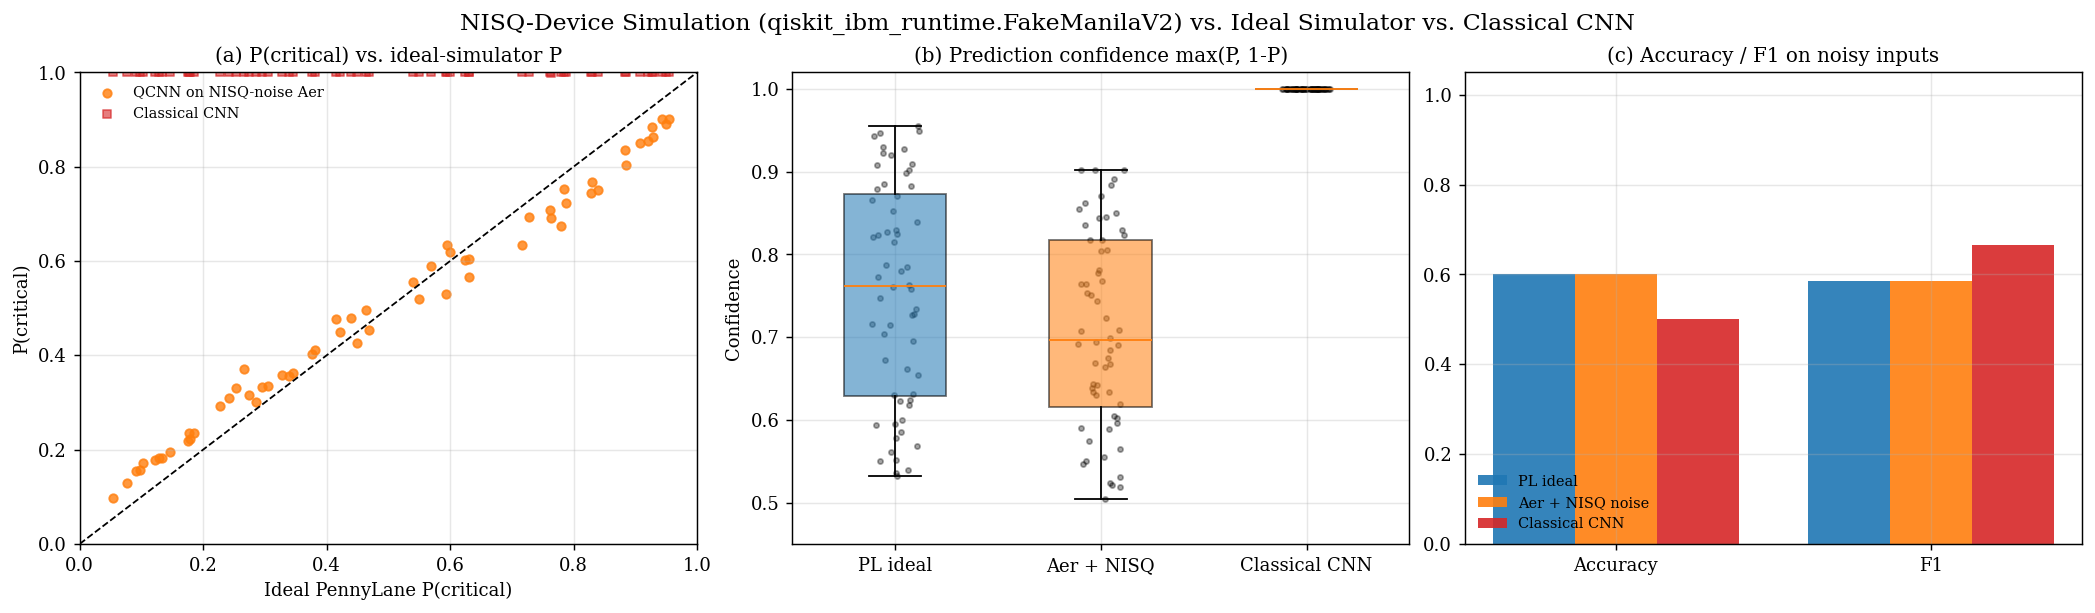

NISQ noise source: qiskit_ibm_runtime.FakeManilaV2 (noise model from backend)
Hardware-transpiled circuit: depth=64, CX=28, ops={'rz': 74, 'sx': 50, 'cx': 28, 'measure': 2}
Conversion check: max |<Z>_Aer(noise-free) - <Z>_PennyLane| = 0.0368 (shot-noise scale ~ 0.033)
Mean |<Z>| shift caused by hardware noise: 0.0790

Inputs: 60 balanced test patches, Gaussian noise at 10 dB; 8192 shots per circuit


,Accuracy,F1,Mean confidence,Mean |P - P_ideal|
Setting,,,,
PL ideal (clean in),0.6333,0.6207,0.7406,0.1447
PL ideal,0.6000,0.5862,0.7534,0.0000
"Aer, no HW noise",0.6000,0.5862,0.7529,0.0060
Aer + NISQ noise,0.5833,0.5763,0.7087,0.0486
Classical CNN,0.5000,0.6667,1.0000,0.5052


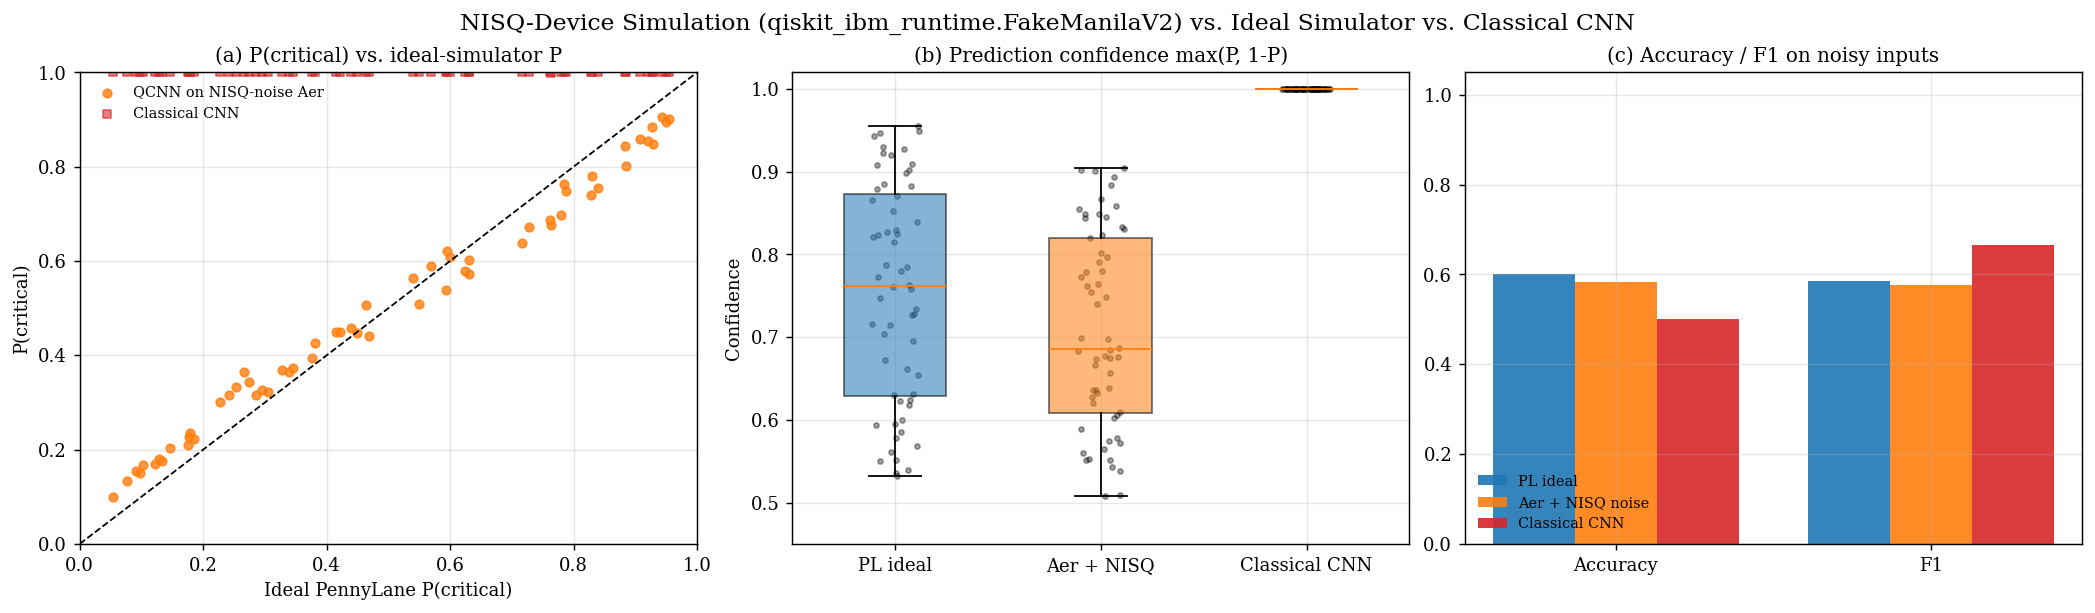

In [7]:
%pip install -q qiskit qiskit-aer qiskit-ibm-runtime

import importlib, math
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error, ReadoutError

assert HAS_PL, "CELL 10 needs PennyLane for the ideal reference simulator."
SHOTS, N_EVAL, INPUT_SNR_DB = 8192, 60, 10
BASIS = ["rz", "sx", "x", "cx", "id"]
q10, cnn10 = SEED0_MODELS["Hybrid QCNN"].eval(), SEED0_MODELS["Classical CNN"].eval()

# ---------------------------------------------------------------------------
# 10.1 PennyLane -> Qiskit conversion (parameterised in the data angles)
# ---------------------------------------------------------------------------
def pl_unitary(weights, wires):
    """Exact 4x4 matrix of an ArbitraryUnitary, wires[0] = most-significant bit."""
    return qml.matrix(qml.ArbitraryUnitary(weights, wires=list(wires)))

def build_qiskit_qcnn(w):
    """w: dict of numpy weights. Returns (circuit, [z0..z3]). Mirrors CELL 5 gate-for-gate."""
    zv = ParameterVector("z", N_QUBITS); qc = QuantumCircuit(N_QUBITS, 2)
    for i in range(N_QUBITS):                                   # RY/RZ angle encoding
        qc.ry(zv[i], i); qc.rz(zv[i], i)
    for i in range(N_QUBITS):                                   # AQFS gains + entangling ring
        qc.ry(float(w["aqfs_gain"][i]) * zv[i], i)
    for i in range(N_QUBITS):
        qc.crz(float(w["aqfs_phi"][i]), i, (i + 1) % N_QUBITS)
    # Qiskit's first qarg is the LEAST-significant bit -> pass wires reversed
    qc.append(UnitaryGate(pl_unitary(w["conv1"][0], [0, 1])), [1, 0])
    qc.append(UnitaryGate(pl_unitary(w["conv1"][1], [2, 3])), [3, 2])
    qc.cry(float(w["pool"][0]), 1, 0); qc.cry(float(w["pool"][1]), 3, 2)
    qc.append(UnitaryGate(pl_unitary(w["conv2"][0], [0, 2])), [2, 0])
    qc.measure(0, 0); qc.measure(2, 1)                          # <Z0>, <Z2>; qubits 1,3 traced out
    return qc, list(zv)

W_NP = {k: v.detach().cpu().double().numpy() for k, v in q10.qlayer.qnode_weights.items()}
template, zparams = build_qiskit_qcnn(W_NP)

# ---------------------------------------------------------------------------
# 10.2 NISQ backend + noise model
# ---------------------------------------------------------------------------
def custom_ibm_like_noise():
    """Fallback: IBM-Falcon-like numbers (T1~110us, T2~90us, 1q err 3e-4, CX err 9e-3, readout 2%)."""
    t1, t2, t1q, t2q = 110e-6, 90e-6, 35e-9, 300e-9
    nm = NoiseModel()
    e1 = depolarizing_error(3e-4, 1).compose(thermal_relaxation_error(t1, t2, t1q))
    e2 = depolarizing_error(9e-3, 2).compose(
        thermal_relaxation_error(t1, t2, t2q).expand(thermal_relaxation_error(t1, t2, t2q)))
    nm.add_all_qubit_quantum_error(e1, ["sx", "x"]); nm.add_all_qubit_quantum_error(e2, ["cx"])
    nm.add_all_qubit_readout_error(ReadoutError([[0.98, 0.02], [0.02, 0.98]]))
    line = [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2]]
    return dict(name="custom IBM-like noise model (linear 4q)", sim=AerSimulator(noise_model=nm),
                tkw=dict(basis_gates=BASIS, coupling_map=line))

def get_nisq_backend():
    for mod_name in ("qiskit_ibm_runtime.fake_provider", "qiskit.providers.fake_provider"):
        try: mod = importlib.import_module(mod_name)
        except Exception: continue
        for cls_name in ("FakeManilaV2", "FakeManila", "FakeAucklandV2", "FakeAuckland"):
            cls = getattr(mod, cls_name, None)
            if cls is None: continue
            try:
                be = cls()
                return dict(name=f"{mod_name.split('.')[0]}.{cls_name} (noise model from backend)",
                            sim=AerSimulator.from_backend(be), tkw=dict(backend=be))
            except Exception as ex:
                print(f"  skipped {cls_name}: {type(ex).__name__}")
    print("No fake IBM backend importable -> using custom IBM-like noise model.")
    return custom_ibm_like_noise()

NISQ = get_nisq_backend()
print("NISQ noise source:", NISQ["name"])
tmpl_hw = transpile(template, optimization_level=1, seed_transpiler=7, **NISQ["tkw"])
tmpl_ideal = transpile(template, basis_gates=BASIS, optimization_level=1, seed_transpiler=7)
ops = tmpl_hw.count_ops()
print(f"Hardware-transpiled circuit: depth={tmpl_hw.depth()}, CX={ops.get('cx', 0)}, ops={dict(ops)}")

def run_expvals(sim, tmpl, Z, shots=SHOTS):
    """Bind angles per sample, run in one batch, return <Z0>,<Z2> -> (B,2)."""
    circs = [tmpl.assign_parameters({p: float(v) for p, v in zip(zparams, z)}) for z in Z]
    res = sim.run(circs, shots=shots).result()
    out = np.zeros((len(Z), 2))
    for i in range(len(Z)):
        counts = res.get_counts(i); tot = sum(counts.values())
        for key, c in counts.items():
            bits = key.replace(" ", "")                          # bits[-1]=clbit0 (qubit 0), bits[-2]=clbit1 (qubit 2)
            out[i, 0] += c * (1 if bits[-1] == "0" else -1)
            out[i, 1] += c * (1 if bits[-2] == "0" else -1)
        out[i] /= tot
    return out

# ---------------------------------------------------------------------------
# 10.3 Balanced noisy test subset (identical inputs for all three settings)
# ---------------------------------------------------------------------------
rng10 = np.random.default_rng(0)
idx = np.concatenate([rng10.choice(np.where(yp_te.numpy() == c)[0], N_EVAL // 2, replace=False) for c in (0, 1)])
rng10.shuffle(idx)
X_clean_sub, y_sub = Xp_te[idx], yp_te[idx]
X_noisy_sub = add_gaussian_noise(X_clean_sub, INPUT_SNR_DB, np.random.default_rng(123))
to_angles = lambda feats: (math.pi * torch.tanh(feats.float())).double()      # same scaling as the model's forward()
Z_noisy, Z_clean = to_angles(pca.transform(X_noisy_sub)), to_angles(pca.transform(X_clean_sub))

# ---------------------------------------------------------------------------
# 10.4 Inference in all settings
# ---------------------------------------------------------------------------
def head_logits(q_np):                                           # classical head on top of measured <Z>
    with torch.no_grad():
        return q10.head(torch.tensor(q_np, dtype=torch.float32)).squeeze(-1)

with torch.no_grad():
    q_ideal_clean = q10.qlayer(Z_clean.float()).numpy()
    q_ideal_noisy = q10.qlayer(Z_noisy.float()).numpy()
    L_cnn = cnn10(X_noisy_sub)
q_aer_ideal = run_expvals(AerSimulator(), tmpl_ideal, Z_noisy.numpy())          # transpilation check (shots only)
q_aer_nisq = run_expvals(NISQ["sim"], tmpl_hw, Z_noisy.numpy())                 # shots + hardware noise

err = np.abs(q_aer_ideal - q_ideal_noisy).max()
print(f"Conversion check: max |<Z>_Aer(noise-free) - <Z>_PennyLane| = {err:.4f} "
      f"(shot-noise scale ~ {3 / math.sqrt(SHOTS):.3f})")
if err > 0.06:
    print("WARNING: Qiskit circuit disagrees with PennyLane beyond shot noise - check gate/qubit mapping.")
print(f"Mean |<Z>| shift caused by hardware noise: {np.abs(q_aer_nisq - q_aer_ideal).mean():.4f}")

L = {"PL ideal (clean in)": head_logits(q_ideal_clean), "PL ideal": head_logits(q_ideal_noisy),
     "Aer, no HW noise": head_logits(q_aer_ideal), "Aer + NISQ noise": head_logits(q_aer_nisq), "Classical CNN": L_cnn}
P = {k: torch.sigmoid(v).numpy() for k, v in L.items()}              # P(critical)
rows = []
for k, lg in L.items():
    a, f = acc_f1(lg, y_sub)
    rows.append({"Setting": k, "Accuracy": a, "F1": f, "Mean confidence": np.maximum(P[k], 1 - P[k]).mean(),
                 "Mean |P - P_ideal|": 0.0 if k == "PL ideal" else np.abs(P[k] - P["PL ideal"]).mean()})
summary10 = pd.DataFrame(rows).set_index("Setting").round(4)
print(f"\nInputs: {N_EVAL} balanced test patches, Gaussian noise at {INPUT_SNR_DB} dB; {SHOTS} shots per circuit")
display(summary10)

# ---------------------------------------------------------------------------
# 10.5 Confidence comparison figure
# ---------------------------------------------------------------------------
KEYS = ["PL ideal", "Aer + NISQ noise", "Classical CNN"]
COL = {"PL ideal": "#1f77b4", "Aer + NISQ noise": "#ff7f0e", "Classical CNN": "#d62728"}
fig10, axs = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

ax = axs[0]
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.scatter(P["PL ideal"], P["Aer + NISQ noise"], c=COL["Aer + NISQ noise"], s=22, alpha=0.8, label="QCNN on NISQ-noise Aer")
ax.scatter(P["PL ideal"], P["Classical CNN"], c=COL["Classical CNN"], s=22, marker="s", alpha=0.6, label="Classical CNN")
ax.set(title="(a) P(critical) vs. ideal-simulator P", xlabel="Ideal PennyLane P(critical)",
       ylabel="P(critical)", xlim=(0, 1), ylim=(0, 1)); ax.legend(frameon=False, fontsize=8)

ax = axs[1]
data = [np.maximum(P[k], 1 - P[k]) for k in KEYS]
bp = ax.boxplot(data, widths=0.5, patch_artist=True, showfliers=False)
for patch, k in zip(bp["boxes"], KEYS): patch.set_facecolor(COL[k]); patch.set_alpha(0.55)
for i, d in enumerate(data, 1):
    ax.scatter(i + np.random.default_rng(i).uniform(-0.12, 0.12, len(d)), d, s=8, c="k", alpha=0.35)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["PL ideal", "Aer + NISQ", "Classical CNN"])
ax.set(title="(b) Prediction confidence max(P, 1-P)", ylabel="Confidence", ylim=(0.45, 1.02))

ax = axs[2]
xb, w3 = np.arange(2), 0.26
for i, k in enumerate(KEYS):
    vals = [summary10.loc[k, "Accuracy"], summary10.loc[k, "F1"]]
    ax.bar(xb + (i - 1) * w3, vals, w3, color=COL[k], alpha=0.9, label=k)
ax.set(title="(c) Accuracy / F1 on noisy inputs", xticks=xb, xticklabels=["Accuracy", "F1"], ylim=(0, 1.05))
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig10.suptitle(f"NISQ-Device Simulation ({NISQ['name'].split(' (')[0]}) vs. Ideal Simulator vs. Classical CNN", fontsize=13)
fig10.savefig("fig5_nisq_confidence.png", bbox_inches="tight", dpi=300)
plt.show()